Training dataset: Data/model_building_data_364cmpds.xlsx
External test set: Data/external_test_set_2689.xlsx
Outputs will be saved to: outputs
Loaded dataset with 364 compounds


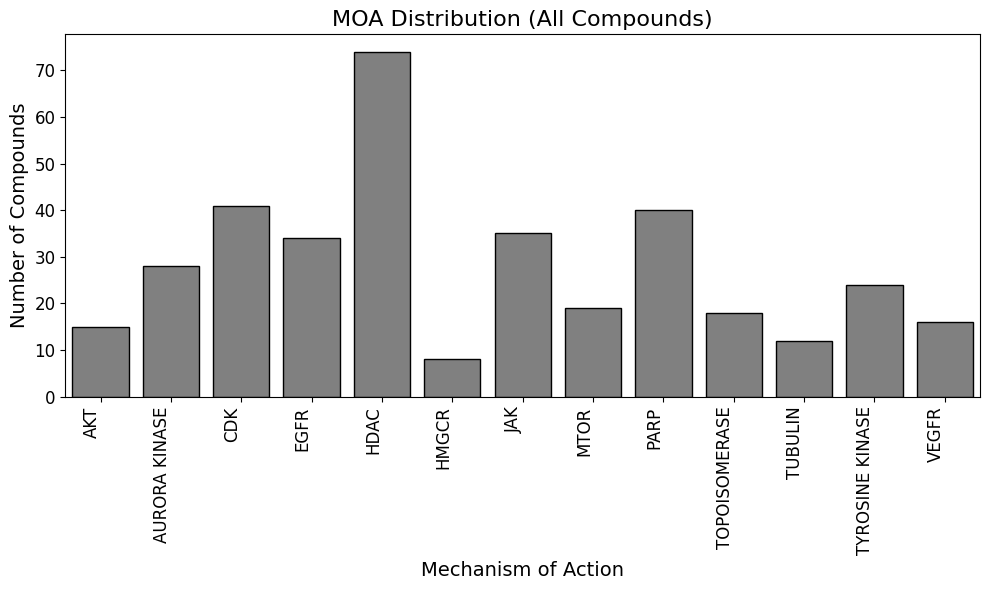

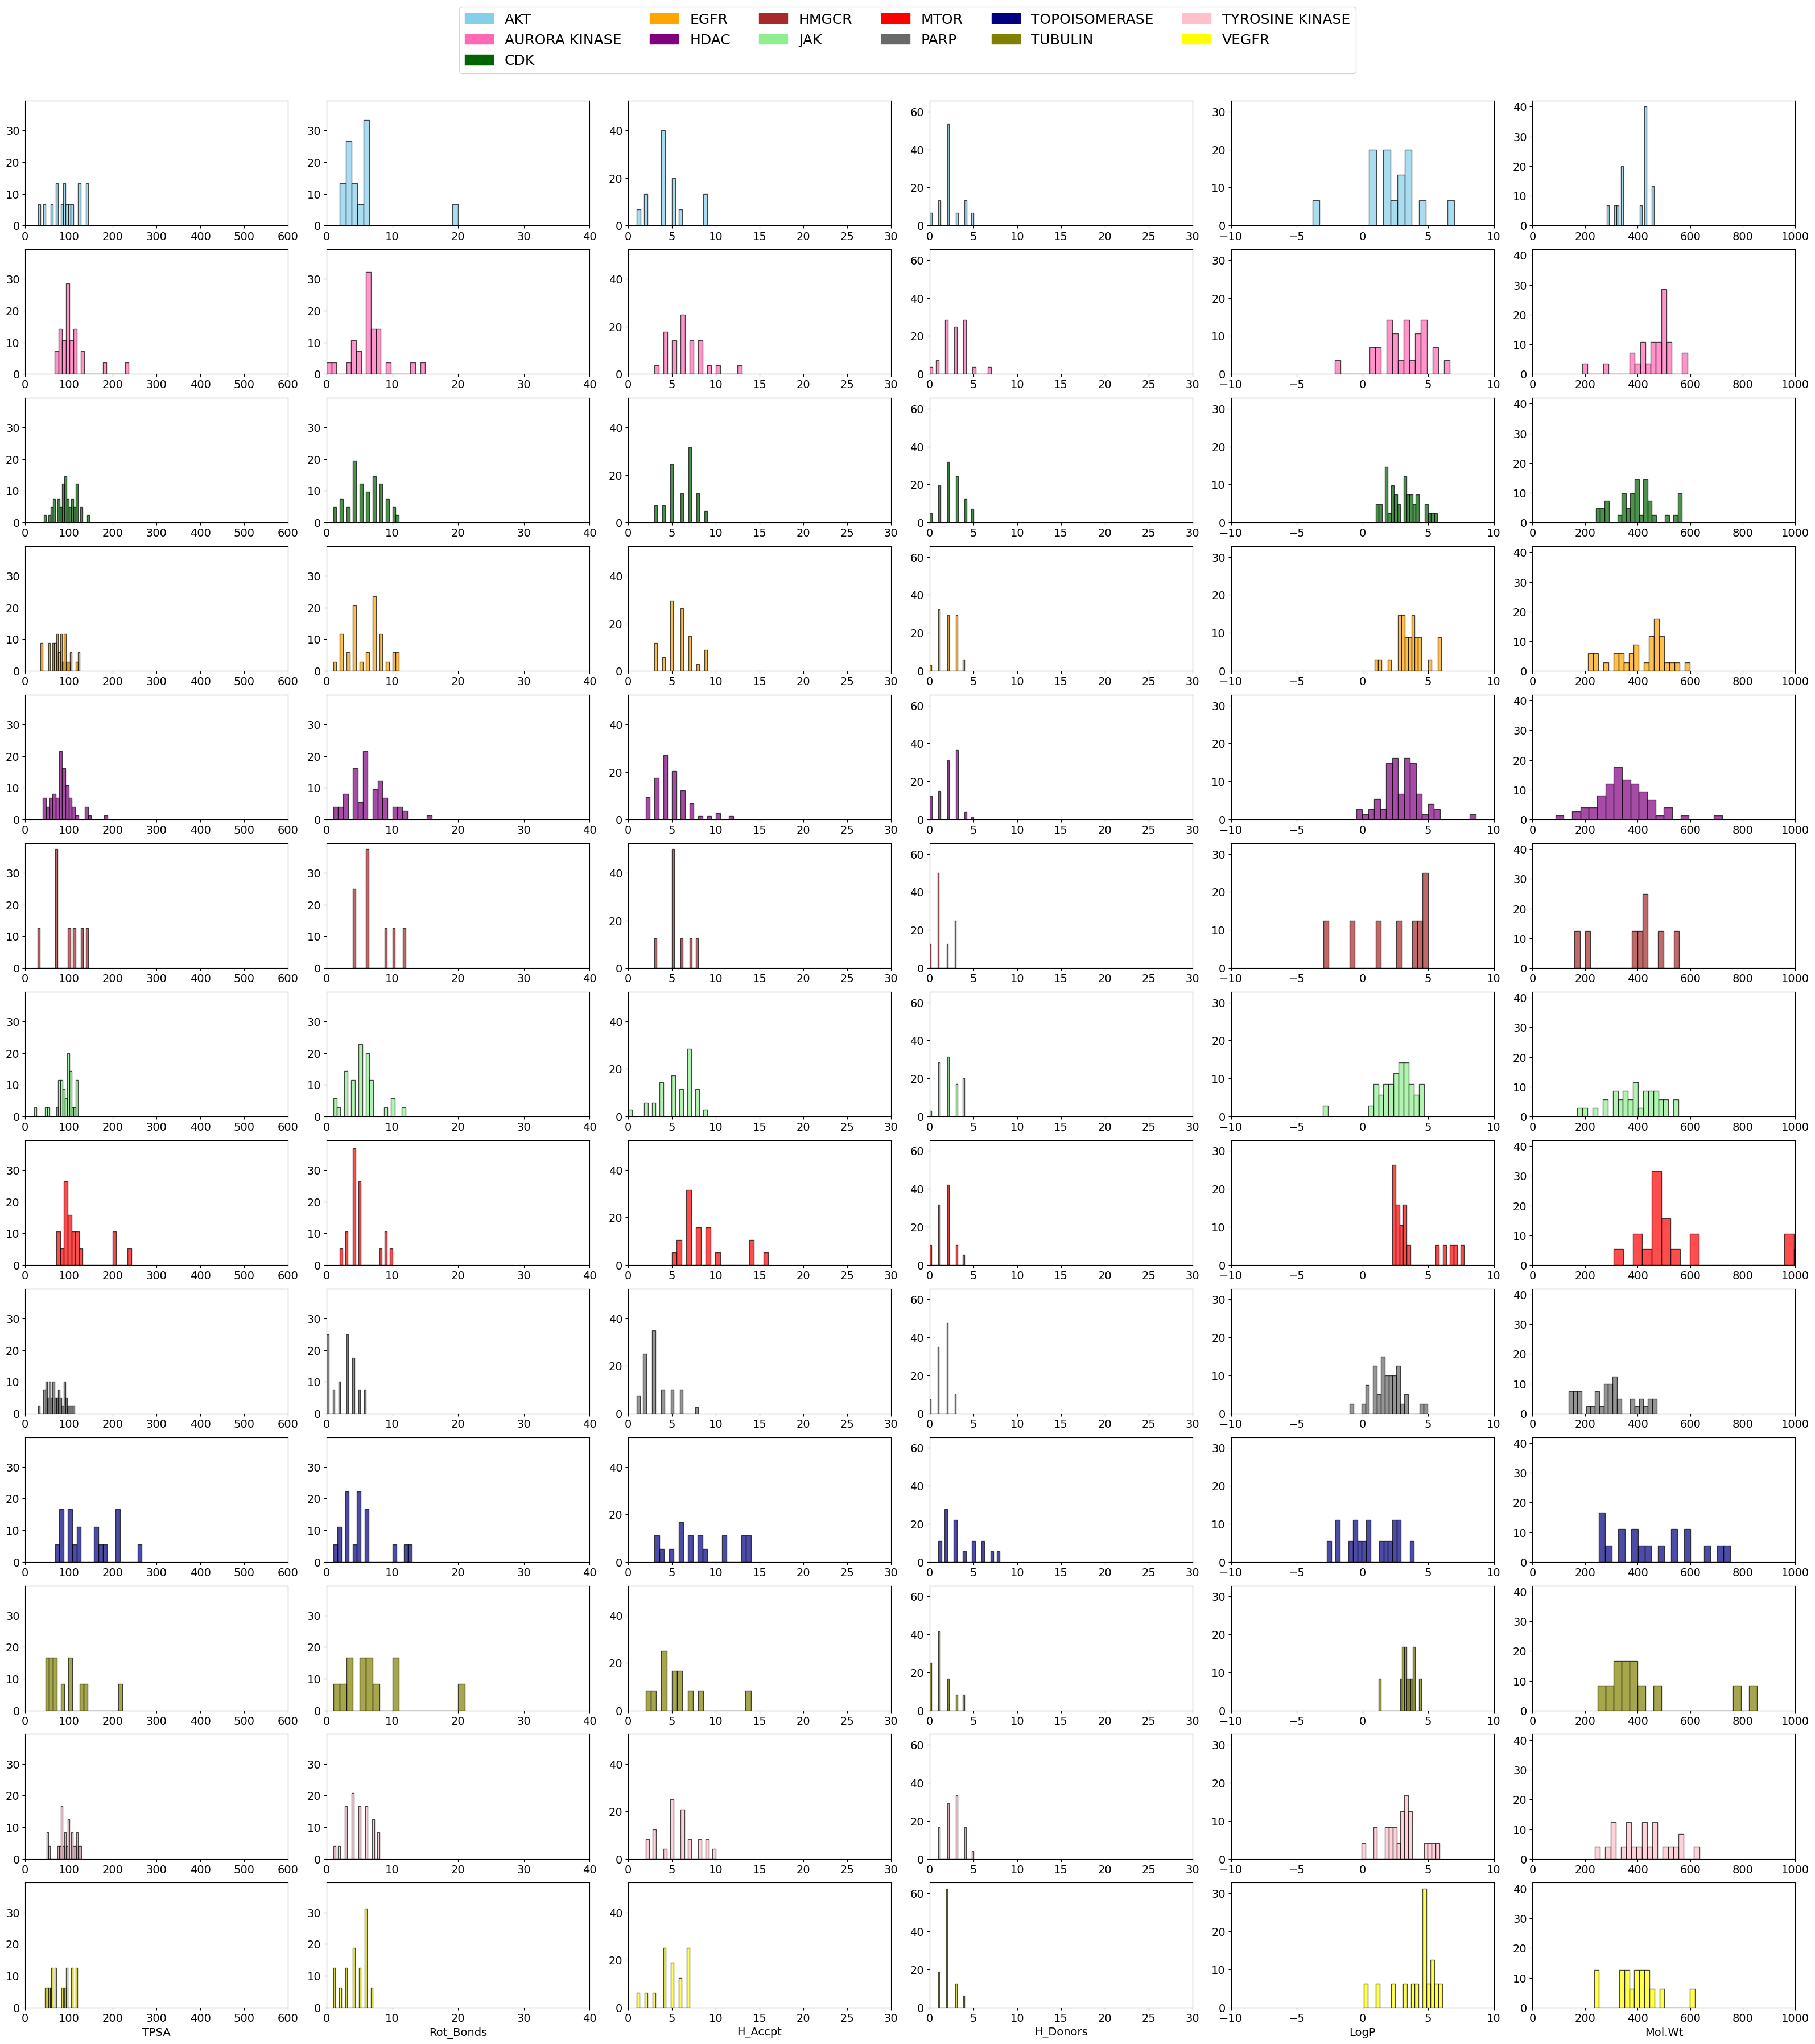

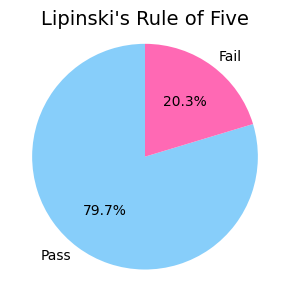

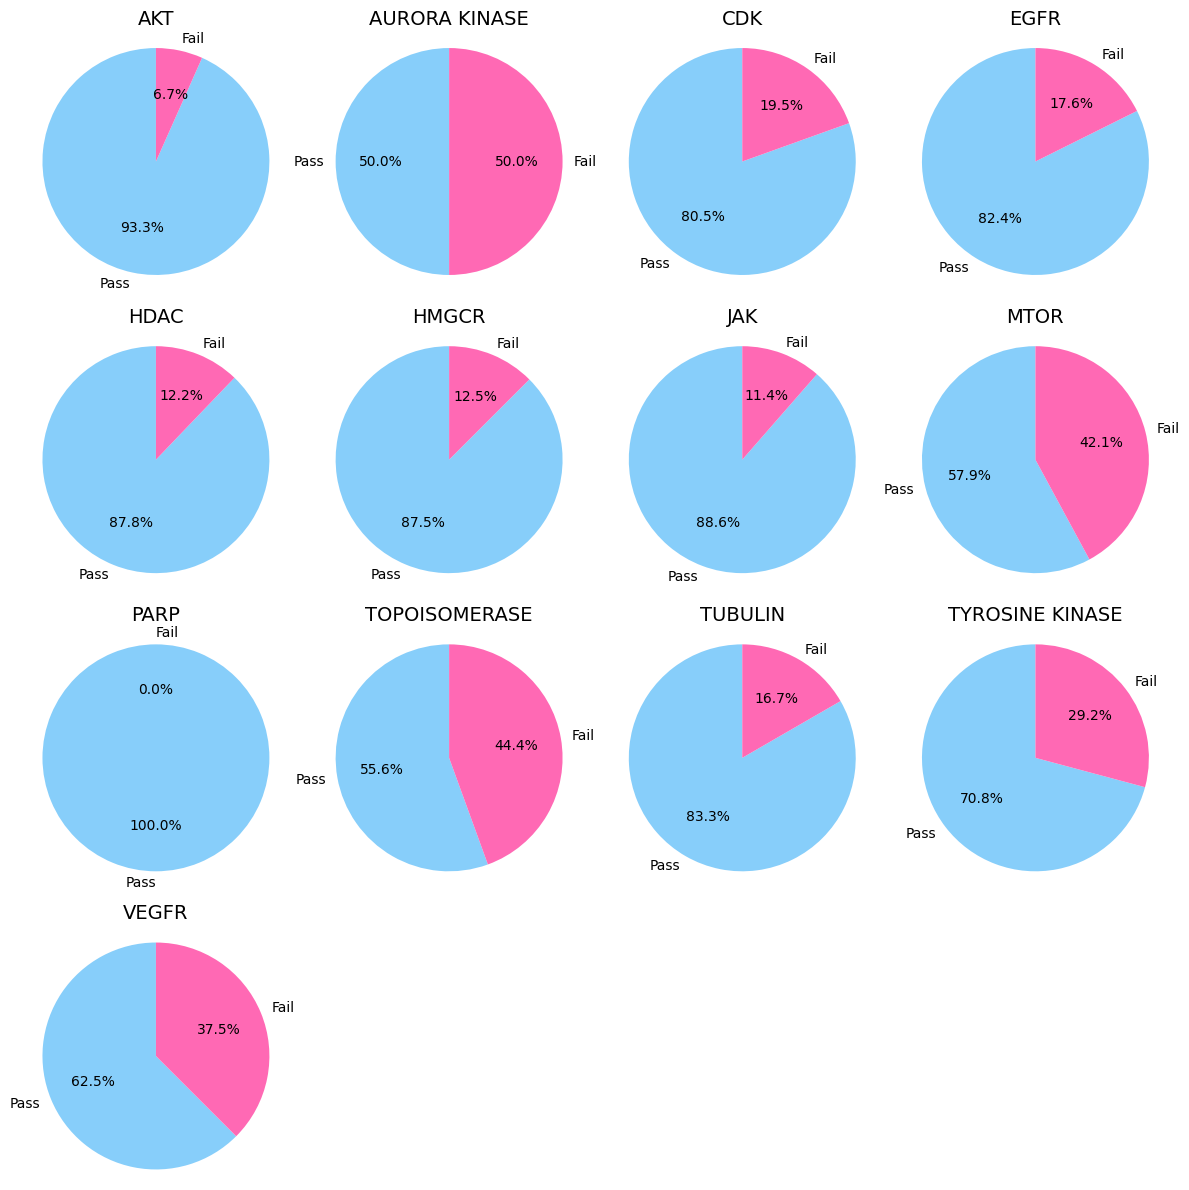

In [21]:
# --- Imports ---
import pandas as pd
from utils_config import load_config
from preprocess import (plot_moa_distribution,
    calculate_descriptors, apply_lipinskis_rule_to_dataset,
    plot_descriptor_histograms_grid, plot_lipinski_pie,
    plot_lipinski_pie_per_moa, plot_cluster_vs_threshold)

# --- Load config ---
cfg = load_config("config.yaml")
train_path = cfg["paths"]["train"]
ext_test_path = cfg["paths"]["external_test"]
outputs_dir = cfg["paths"]["outputs"]

print("Training dataset:", train_path)
print("External test set:", ext_test_path)
print("Outputs will be saved to:", outputs_dir)

# --- Load dataset for model building---
smiles_col = "SMILES_protonated_7.4"
df = pd.read_excel(train_path)
df.dropna(subset=[smiles_col], inplace=True)
print(f"Loaded dataset with {len(df)} compounds")

# --- Compute descriptors ---
descriptor_cols = ["TPSA", "Rot_Bonds", "H_Accpt", "H_Donors", "LogP", "Mol.Wt"]
df[descriptor_cols] = df[smiles_col].apply(calculate_descriptors).apply(pd.Series)

# --- Apply Lipinski ---
df = apply_lipinskis_rule_to_dataset(df)

# --- Generate plots ---

plot_moa_distribution(df, output_path=outputs_dir / "moa_distribution_histogram.png")

plot_descriptor_histograms_grid(df, "moa_label", 
                                output_path=outputs_dir / "descriptor_histograms.png")
plot_lipinski_pie(df, output_path=outputs_dir / "lipinski_rule_pie.png")
plot_lipinski_pie_per_moa(df, output_path=outputs_dir / "lipinski_pie_per_moa.png")


✅ Saved SMILES splits → outputs/stratified_merge_st_vs_tk_smiles.npz
✅ Stratified split completed.
Encoded 7 MOA classes.
      Dataset     |     Shape
------------------------------------
Training set      | (250, 2048)
Training labels   | (250,)
Validation set    | (39, 2048)
Validation labels | (39,)
Test set          | (75, 2048)
Test labels       | (75,)
------------------------------------
Epoch 1/1000


/home/gauss/miniconda3/envs/tf24/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:635: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1688 - loss: 1.7565 - val_accuracy: 0.2051 - val_loss: 1.9298 - learning_rate: 1.0000e-04
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1512 - loss: 1.8138 - val_accuracy: 0.2051 - val_loss: 1.9207 - learning_rate: 1.0000e-04
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2172 - loss: 1.9035 - val_accuracy: 0.2051 - val_loss: 1.9127 - learning_rate: 1.0000e-04
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1995 - loss: 2.0388 - val_accuracy: 0.2051 - val_loss: 1.9055 - learning_rate: 1.0000e-04
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2192 - loss: 1.8027 - val_accuracy: 0.1795 - val_loss: 1.8983 - learning_rate: 1.0000e-04
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2491 - loss: 2.0759 - val_accuracy: 0.2051 - val_loss: 1.8915 - learning_rate: 1.0000e-04
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2282 - loss: 1.6922 

✅ Model saved to outputs/trained_model_stratified_merge_st_vs_tk.h5


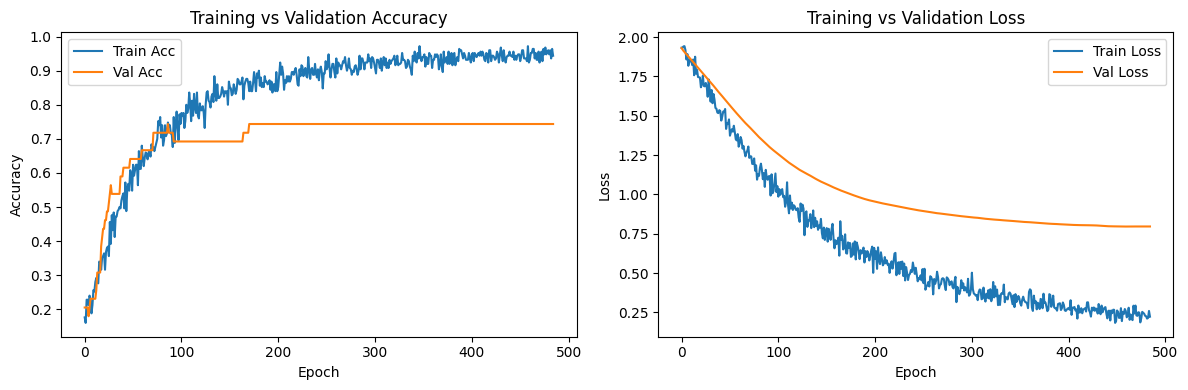

In [22]:
from data_splitting import split_stratified, process_dataset_across_thresholds, prepare_data
from model_train import (plot_moa_bar, run_moa_training_pipeline, plot_training_history)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- User choice 1: MOA merging strategy ---
moa_condition = "merge_st_vs_tk"   # options: "as_is", "merge_tk_egfr_vegfr", "merge_tk_egfr_keep_vegfr",
                                            #"merge_tk_vegfr_keep_egfr", "merge_all_kinases", "merge_st_vs_tk"

# --- User choice 2: Split type ---
split_choice = "stratified"  # options: "structure" or "stratified"

# --- Perform split ---
if split_choice == "stratified":
    df_train, df_val, df_test = split_stratified(df, moa_condition=moa_condition)
    df_split = pd.concat([df_train, df_val, df_test])
    print("✅ Stratified split completed.")
elif split_choice == "structure":
    datasets = process_dataset_across_thresholds(train_path, thresholds=[0.65], moa_condition=moa_condition)
    
    # grab the first key (since we only passed one threshold)
    split_tag = list(datasets.keys())[0]
    df_split = datasets[split_tag]
    print(f"✅ Structure-based split completed: {split_tag}")
else:
    raise ValueError("Invalid split_choice.")


# --- Build label_dict BEFORE training ---
all_moas = sorted(df_split["moa_label"].unique())
label_dict = {moa: idx for idx, moa in enumerate(all_moas)}
df_split["labels"] = df_split["moa_label"].map(label_dict)
print(f"Encoded {len(label_dict)} MOA classes.")

# --- Train the model ---
model_tag = f"{split_choice}_{moa_condition}"
model_save_path = outputs_dir / f"trained_model_{model_tag}.h5"

model, history = run_moa_training_pipeline(df_split, model_save_path, label_dict)

# --- Save trained model ---
model.save(model_save_path)
print(f"✅ Model saved to {model_save_path}")

# --- Training history plot ---
plot_training_history(history, output_path=outputs_dir / f"training_history_{model_tag}.png")


In [23]:
# --- Evaluate on internal and external test set ---
from evaluate import evaluate_test_set

internal_test_df = df_split[df_split["set"] == "test"].copy()

metrics_internal = evaluate_test_set(internal_test_df,model,label_dict,
                                     out_prefix=outputs_dir / f"internal_{model_tag}",
                                     smiles_col="SMILES_protonated_7.4",
    title=f"Internal Test Set ({model_tag})", moa_condition=moa_condition)

# --- Evaluate on external test set ---
ext_test_df = pd.read_excel(ext_test_path).dropna(subset=["SMILES_protonated_7.4"])

metrics_external = evaluate_test_set(ext_test_df,model,label_dict,
                                     out_prefix=outputs_dir / f"external_{model_tag}",
                                     smiles_col="SMILES_protonated_7.4",
title=f"External Test Set ({model_tag})", moa_condition=moa_condition)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step

=== Evaluation: Internal Test Set (stratified_merge_st_vs_tk) ===
+---------------------------------+-------------+----------+--------+
| Category                        |   Precision |   Recall |     F1 |
+=================================+=============+==========+========+
| HDAC                            |      0.8235 |   0.9333 | 0.875  |
+---------------------------------+-------------+----------+--------+
| HMGCR                           |      1      |   1      | 1      |
+---------------------------------+-------------+----------+--------+
| PARP                            |      0.5    |   0.625  | 0.5556 |
+---------------------------------+-------------+----------+--------+
| SERINE/THREONINE PROTEIN KINASE |      0.6    |   0.7143 | 0.6522 |
+---------------------------------+-------------+----------+--------+
| TOPOISOMERASE                   |      1      |   0.75   | 0.8571 |
+---------------------------------+-------------+-----

In [24]:
# --- Tanimoto similarity and scaffold diversity across train, validation, internal test and external test ---

from similarity_across_splits import analyze_train_other_overlap, plot_overlap_bars

# --- Prepare splits ---
train_df = df_split[df_split["set"] == "tr"].copy()
val_df   = df_split[df_split["set"] == "val"].copy()
test_df  = df_split[df_split["set"] == "test"].copy()
ext_df   = pd.read_excel(ext_test_path).dropna(subset=["SMILES_protonated_7.4"])

# --- Compute overlaps ---
results = {
    "Train_vs_Val": analyze_train_other_overlap(train_df, val_df, label_dict, other_name="Val"),
    "Train_vs_InternalTest": analyze_train_other_overlap(train_df, test_df, label_dict, other_name="Test"),
    "Train_vs_ExternalTest": analyze_train_other_overlap(train_df, ext_df, label_dict, other_name="External")
}

# --- Plot grouped bar plots ---
plot_overlap_bars(results, output_dir=outputs_dir, prefix=f"overlap_{model_tag}")


[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerator
[14:21:18] DEPRECATION WARNING: please use MorganGenerat